In [28]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/iamsouravbanerjee/customer-shopping-trends-dataset/shopping_trends.csv
/kaggle/input/datasets/iamsouravbanerjee/customer-shopping-trends-dataset/shopping_trends_updated.csv


# Objective
The goal of this analysis is to study customer shopping behavior,
purchase patterns, demographics, and spending trends.

In [29]:
df=pd.read_csv("/kaggle/input/datasets/iamsouravbanerjee/customer-shopping-trends-dataset/shopping_trends_updated.csv")
df

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3895,3896,40,Female,Hoodie,Clothing,28,Virginia,L,Turquoise,Summer,4.2,No,2-Day Shipping,No,No,32,Venmo,Weekly
3896,3897,52,Female,Backpack,Accessories,49,Iowa,L,White,Spring,4.5,No,Store Pickup,No,No,41,Bank Transfer,Bi-Weekly
3897,3898,46,Female,Belt,Accessories,33,New Jersey,L,Green,Spring,2.9,No,Standard,No,No,24,Venmo,Quarterly
3898,3899,44,Female,Shoes,Footwear,77,Minnesota,S,Brown,Summer,3.8,No,Express,No,No,24,Venmo,Weekly


In [30]:
df.head()
df.info()
df.describe()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   object 
 3   Item Purchased          3900 non-null   object 
 4   Category                3900 non-null   object 
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   object 
 7   Size                    3900 non-null   object 
 8   Color                   3900 non-null   object 
 9   Season                  3900 non-null   object 
 10  Review Rating           3900 non-null   float64
 11  Subscription Status     3900 non-null   object 
 12  Shipping Type           3900 non-null   object 
 13  Discount Applied        3900 non-null   object 
 14  Promo Code Used         3900 non-null   

(3900, 18)

The dataset contains customer demographic and transaction-related data.
There are 3900 rows and 18 columns.
No major missing value issues were observed.

In [31]:
df.isnull().sum()
df.drop_duplicates(inplace=True)

Duplicate rows were removed.
Missing values were handled appropriately based on column type.

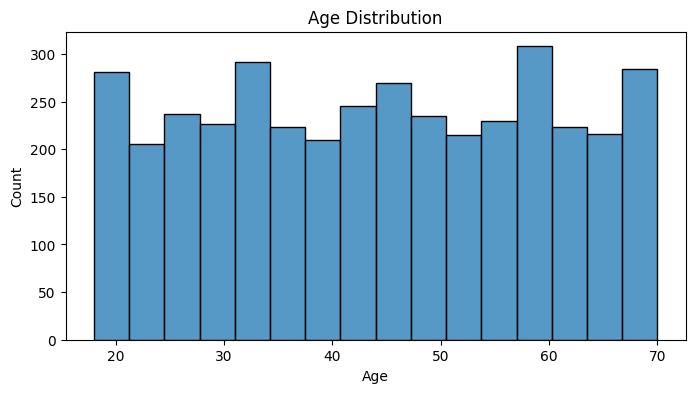

In [32]:
plt.figure(figsize=(8,4))
sns.histplot(df["Age"])
plt.title("Age Distribution")
plt.show()

Most customers fall between ages 50–60, indicating a relatively older customer base.

<Axes: xlabel='Gender', ylabel='count'>

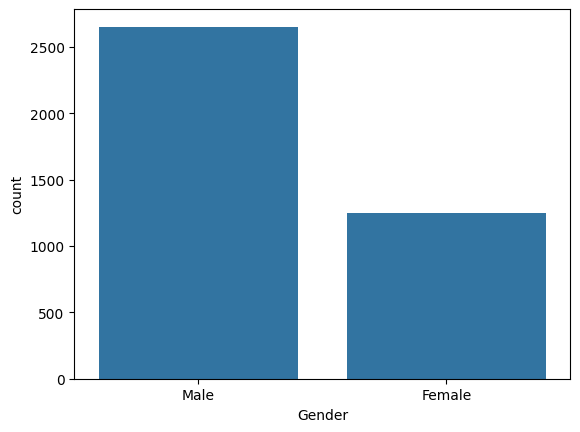

In [33]:
sns.countplot(x="Gender",data=df)

Male customers appear more frequent than female customers.

<Axes: xlabel='Category', ylabel='Purchase Amount (USD)'>

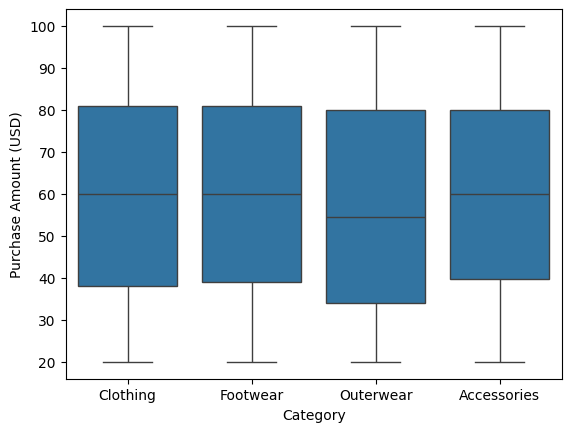

In [34]:
sns.boxplot(
    x="Category",
    y="Purchase Amount (USD)",
    data=df
)

<Axes: >

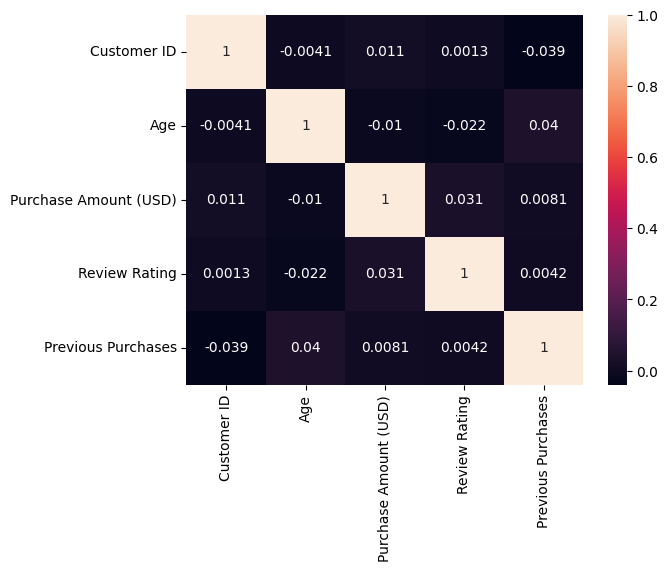

In [35]:
corr=df.corr(numeric_only=True)
sns.heatmap(corr,annot=True)

Purchase amount shows moderate correlation with previous purchases.

In [ ]:
numeric_cols=df.select_dtypes(include="number").columns
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[
        (df[col] < lower) |
        (df[col] > upper)
    ]
    print(f"{col}: {len(outliers)} outliers")

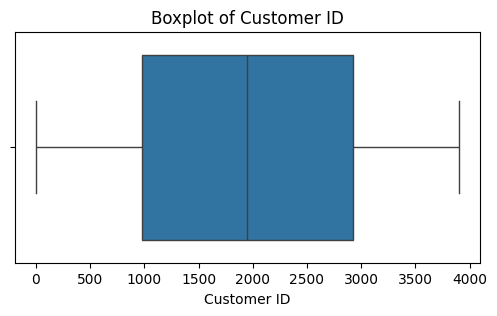

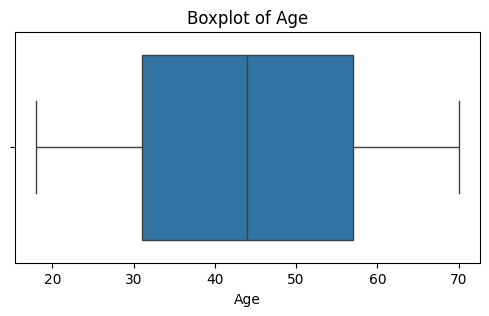

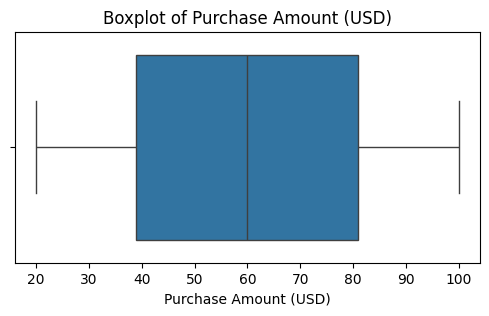

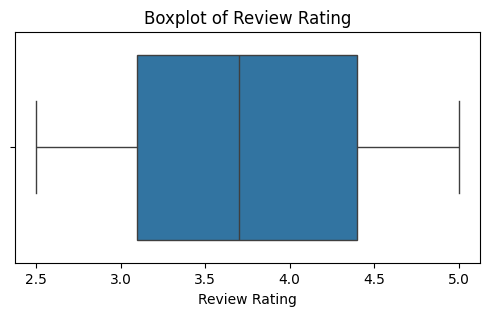

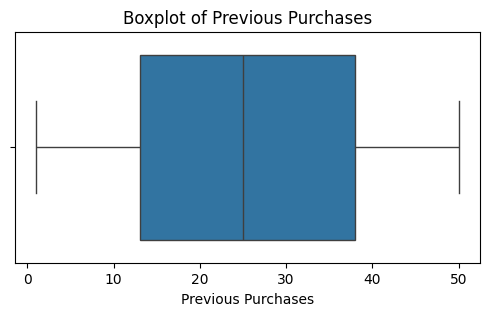

In [40]:
for col in numeric_cols:

    plt.figure(figsize=(6,3))

    sns.boxplot(x=df[col])

    plt.title(f"Boxplot of {col}")

    plt.show()

The columns contains several high-value outliers.
These may represent premium customers rather than data errors.

# Final Insights

- Outerwear is the most purchased category.
- High-spending customers are relatively few.
- Subscription users purchase more frequently.
- Purchase amount contains several high-value outliers.